In [16]:
import pandas as pd
import numpy as np

import scipy.stats as stats # this for plotting the qq plots

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [17]:
df = pd.read_csv('train.csv', usecols = ['Age', 'Fare', 'Survived'])

In [18]:
df.isnull().sum()

,0
Survived,0
Age,177
Fare,0


In [19]:
df['Age'] = df['Age'].fillna(df['Age'].mean()) # imputing missing values with the mean value of the feature

In [20]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [21]:
# extracting input columns as x and output column as y
X = df.iloc[:, 1:3] # columns indexed 1 and 2 are my input features
y = df.iloc[:, 0] # the first column (indexed 0)is my output feature

In [22]:
# splitting the data into test and train splits
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state= 42)

/tmp/ipykernel_1413/2408004972.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])


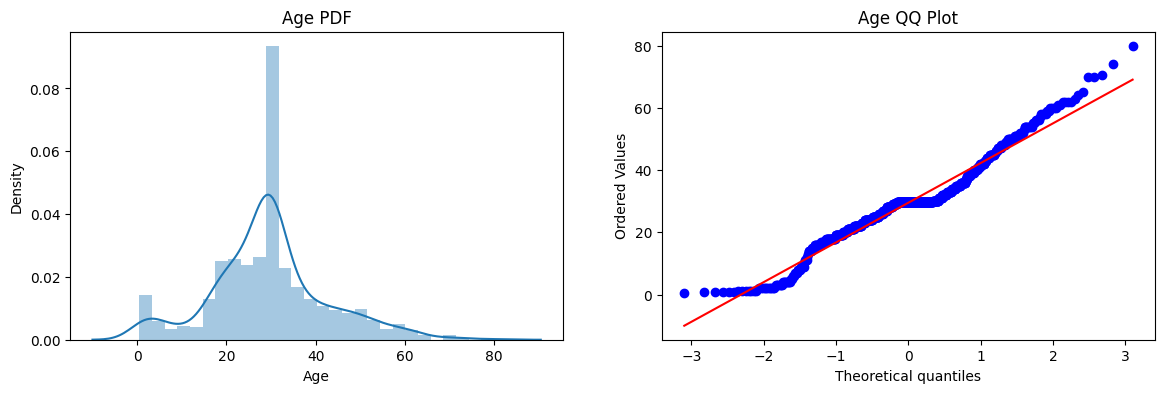

In [23]:
# let's see what the distribution of the data looks like right now
plt.figure(figsize = (14,4))
plt.subplot(1,2,1)
sns.distplot(X_train['Age'])
plt.title('Age PDF')

plt.subplot(1,2,2)
stats.probplot(X_train['Age'], dist = 'norm', plot = plt)
plt.title('Age QQ Plot')

plt.show()

fairly normally distributed

/tmp/ipykernel_1413/4030791554.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])


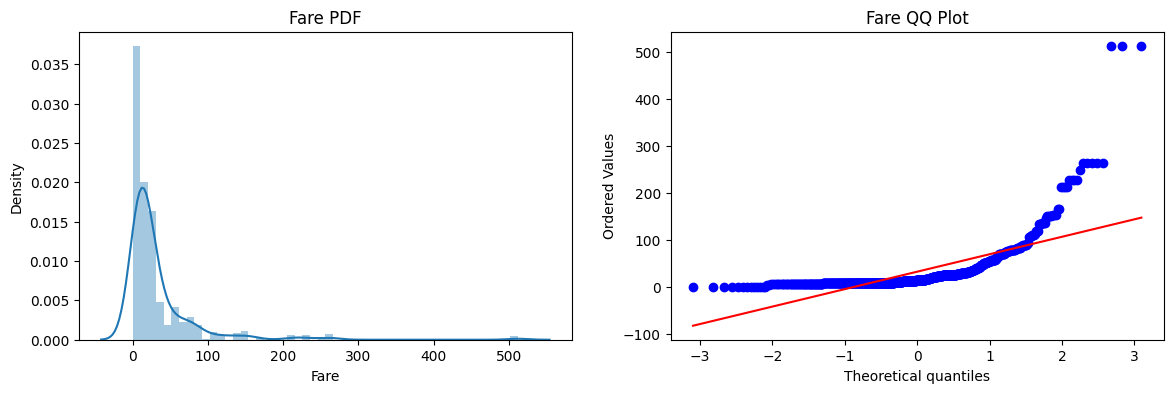

In [25]:
plt.figure(figsize = (14,4))
plt.subplot(1,2,1)
sns.distplot(X_train['Fare'])
plt.title('Fare PDF')

plt.subplot(1,2,2)
stats.probplot(X_train['Fare'], dist = 'norm', plot = plt)
plt.title('Fare QQ Plot')

plt.show()

not at all normally distributed

LET'S SEE HOW DOES TWO ML MODELS PERFORM WITHOUT ANY CHANGES TO THE DATA

In [29]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [31]:
clf.fit(X_train, y_train)
clf2.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(accuracy_score(y_test, y_pred1))

0.6480446927374302
0.6871508379888268


NOW WE USE TRANSFORMERS

In [33]:
trf = FunctionTransformer(np.log1p)

In [34]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

NOW WE GIVE THE TRANSFORMED DATA TO THE TWO MODELS TO SEE HOW THE RESULT CHANGE FOR US

In [35]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed, y_train)
clf2.fit(X_train_transformed, y_train)

y_pred = clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)

print(accuracy_score(y_test, y_pred))
print(accuracy_score(y_test, y_pred1))

0.6815642458100558
0.6871508379888268


WE CAN SEE THAT THE ACCURACY OF A LINEAR MODEL LIKE THE LOGISTIC REGRESSION INCRESED WHILE THE ACCURACY OF THE DECISION TREE MODEL REMAINED THE SAME

NOW LET US SEE HOW DOES THE DATA LOOKS LIKE

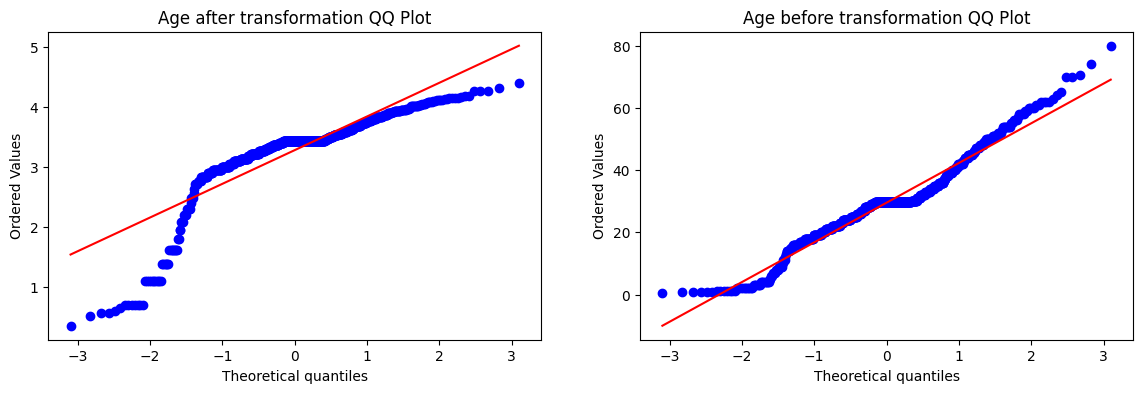

In [37]:
plt.figure(figsize = (14,4))
plt.subplot(1,2,1)
stats.probplot(X_train_transformed['Age'], dist = 'norm', plot = plt)
plt.title('Age after transformation QQ Plot')

plt.subplot(1,2,2)
stats.probplot(X_train['Age'], dist = 'norm', plot = plt)
plt.title('Age before transformation QQ Plot')

plt.show()
# the log transformation did not improve the distribution of the age feature

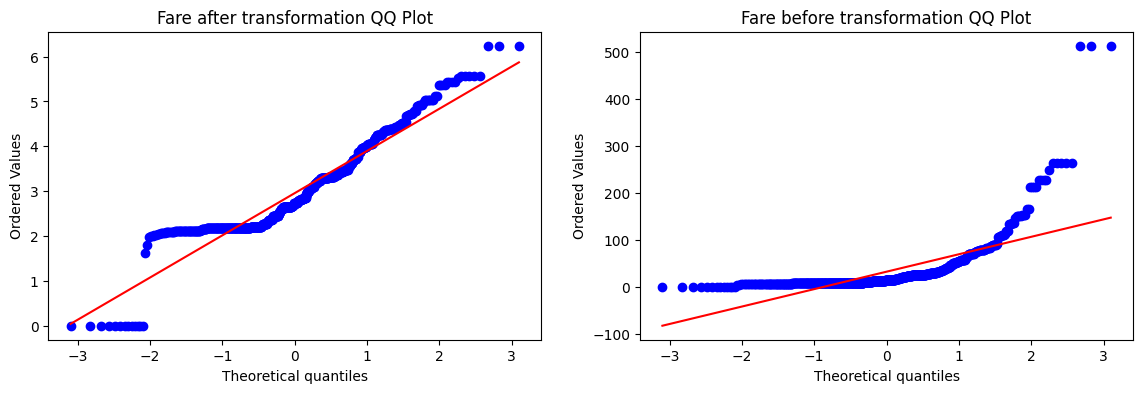

In [39]:
plt.figure(figsize = (14,4))
plt.subplot(1,2,1)
stats.probplot(X_train_transformed['Fare'], dist = 'norm', plot = plt)
plt.title('Fare after transformation QQ Plot')

plt.subplot(1,2,2)
stats.probplot(X_train['Fare'], dist = 'norm', plot = plt)
plt.title('Fare before transformation QQ Plot')

plt.show()
# but there is quite a lot of improvement in the ditribution of the fare plot

NOW LET US APPLY THE TRANSFORMATION TO ONLY THE FARE COLUMN AND SEE HOW OUR MODELS PREDICT, DO THEY IMPROVE OR DO THEY WORSEN.

In [40]:
trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

In [42]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)

y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred2))
# not a huge difference, hence the transformation of age was not necessary

Accuracy LR 0.6703910614525139
Accuracy DT 0.664804469273743


LET'S TRY OTHER FUNCTIONS

In [43]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]

    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')

    X_trans = trf.fit_transform(X)

    clf = LogisticRegression()

    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))

    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()

Accuracy 0.6431335830212235


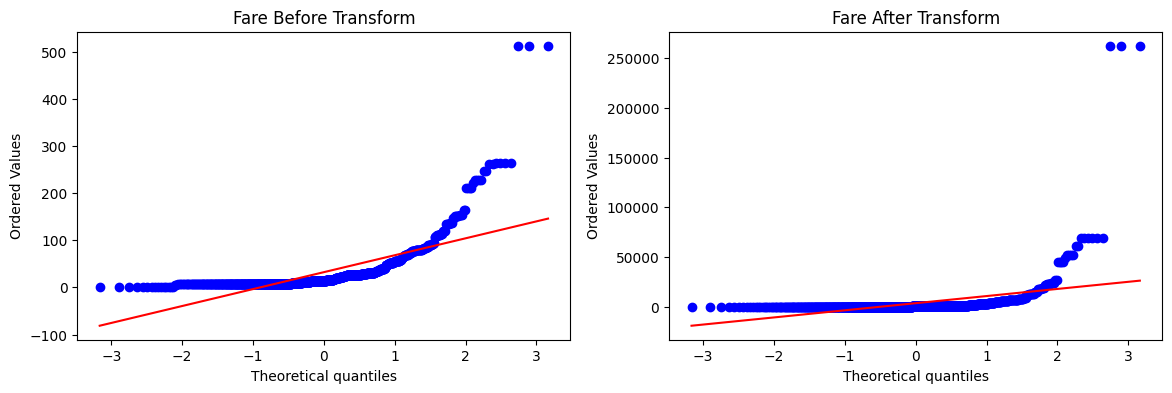

In [45]:
apply_transform(lambda x : x**2)

Accuracy 0.6262796504369538


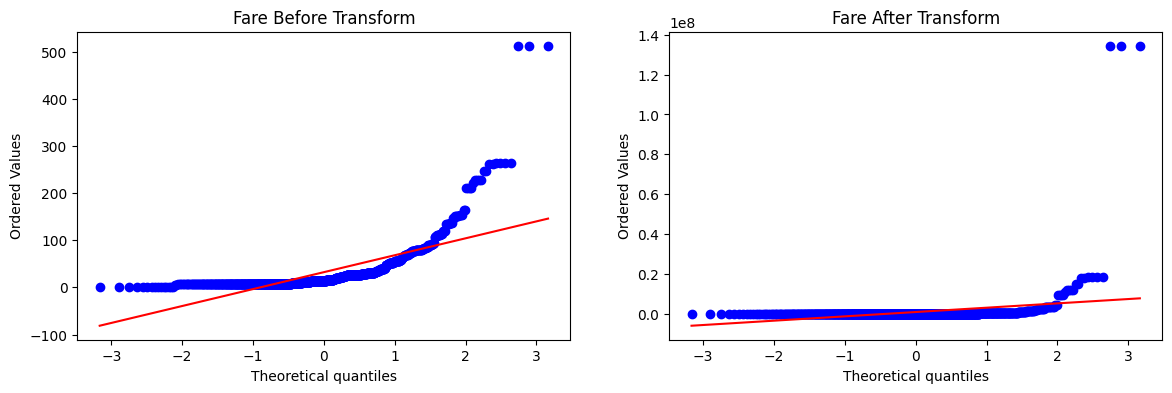

In [46]:
apply_transform(lambda x : x**3)

AND YOU CAN PASS ANY FUNCTION OF YOUR CHOICE AND SEE HOW THE ACCURACY CHANGES FOR A LOGISTIC REGRESSION MODEL